# MNIST Neural Network Classification Project
## Introduction

I extended this project by replacing the original fully connected network with a convolutional neural network (CNN). Unlike a dense network that treats pixels independently, the CNN learns spatial hierarchies of visual features such as edges, strokes, and digit components. This allows the model to better capture the structure of handwritten digits and improves generalization.

I evaluated the CNN using the same training pipeline as before, including learning curves, validation accuracy tracking, confusion matrices, and misclassification visualizations. This enables a direct comparison between the CNN and the earlier baseline model.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# Split training into train/validation
indices = list(range(len(full_train_dataset)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_dataset = Subset(full_train_dataset, train_idx)
val_dataset   = Subset(full_train_dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.93MB/s]


## Model and Training Approach

To perform digit classification, I trained a convolutional neural network that processes images in their original 28×28 spatial format rather than flattening them immediately.

The CNN consists of two convolutional layers (32 and 64 filters, 3×3 kernels) with ReLU activations, a max pooling layer to reduce spatial dimensions, dropout layers to reduce overfitting, and two fully connected layers (128 → 10) for final classification. The architecture allows the model to first learn low-level visual features (edges and curves) and then combine them into higher-level digit representations.

The dataset was split into training, validation, and test sets. The model was trained using the Adam optimizer and cross-entropy loss. After each epoch, validation accuracy was computed, and the model checkpoint with the highest validation accuracy was saved. This ensures that the final test evaluation uses the model that generalized best to unseen data.

In [ ]:
class CNNNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Conv layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)

        # Pooling & dropout
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Input: (batch, 1, 28, 28)
        x = self.relu(self.conv1(x))   # -> (batch, 32, 26, 26)
        x = self.relu(self.conv2(x))   # -> (batch, 64, 24, 24)
        x = self.pool(x)               # -> (batch, 64, 12, 12)
        x = self.dropout1(x)

        x = x.view(x.size(0), -1)      # Flatten
        x = self.relu(self.fc1(x))
        x = self.dropout2(x)

        return self.fc2(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 30
best_val_acc = 0.0

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---- Validation ----
    model.eval()
    correct = 0
    total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_mnist_model.pth")

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

Epoch 1/30 | Train Loss: 0.2712 | Val Loss: 0.0642 | Val Acc: 0.9804
Epoch 2/30 | Train Loss: 0.0976 | Val Loss: 0.0503 | Val Acc: 0.9858
Epoch 3/30 | Train Loss: 0.0756 | Val Loss: 0.0441 | Val Acc: 0.9870
Epoch 4/30 | Train Loss: 0.0640 | Val Loss: 0.0402 | Val Acc: 0.9891
Epoch 5/30 | Train Loss: 0.0512 | Val Loss: 0.0382 | Val Acc: 0.9888
Epoch 6/30 | Train Loss: 0.0477 | Val Loss: 0.0413 | Val Acc: 0.9880
Epoch 7/30 | Train Loss: 0.0429 | Val Loss: 0.0378 | Val Acc: 0.9892
Epoch 8/30 | Train Loss: 0.0382 | Val Loss: 0.0378 | Val Acc: 0.9900
Epoch 9/30 | Train Loss: 0.0337 | Val Loss: 0.0369 | Val Acc: 0.9897
Epoch 10/30 | Train Loss: 0.0322 | Val Loss: 0.0347 | Val Acc: 0.9908
Epoch 11/30 | Train Loss: 0.0273 | Val Loss: 0.0375 | Val Acc: 0.9901
Epoch 12/30 | Train Loss: 0.0270 | Val Loss: 0.0382 | Val Acc: 0.9898
Epoch 13/30 | Train Loss: 0.0244 | Val Loss: 0.0376 | Val Acc: 0.9915
Epoch 14/30 | Train Loss: 0.0218 | Val Loss: 0.0371 | Val Acc: 0.9912
Epoch 15/30 | Train Loss: 0.0

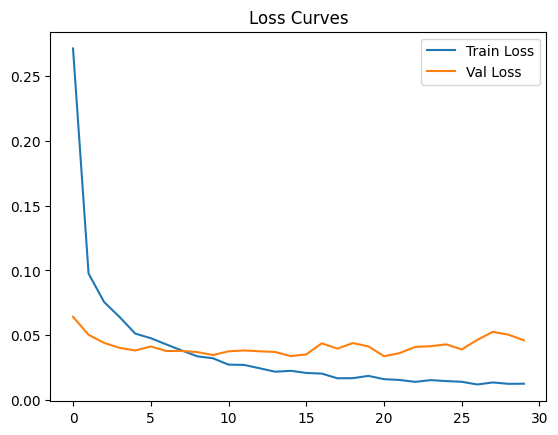

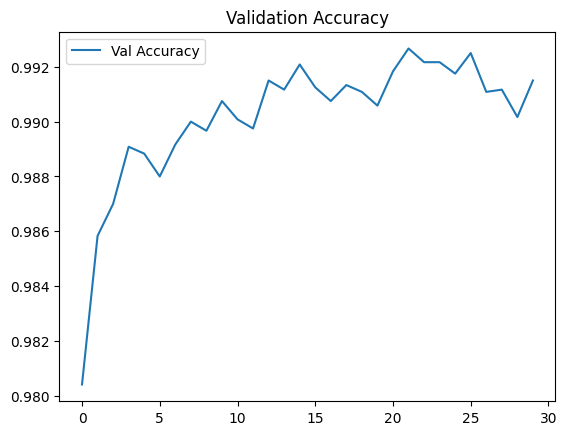

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curves")
plt.show()

plt.figure()
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Validation Accuracy")
plt.show()

## Training Results

Over the course of training, the model’s performance improved rapidly. Validation accuracy started at approximately 98% in the first epoch and increased to over 99%, eventually reaching around 99.2–99.3%. This shows that the CNN quickly learned meaningful visual features and refined them over time.

The loss curves show a typical deep learning pattern: training loss decreases steadily, while validation loss plateaus and fluctuates slightly in later epochs. This suggests mild overfitting, which is expected once the model has already learned most of the useful structure in the data. However, validation accuracy remains consistently high, indicating strong generalization.

In [ ]:
model.load_state_dict(torch.load("best_mnist_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9923


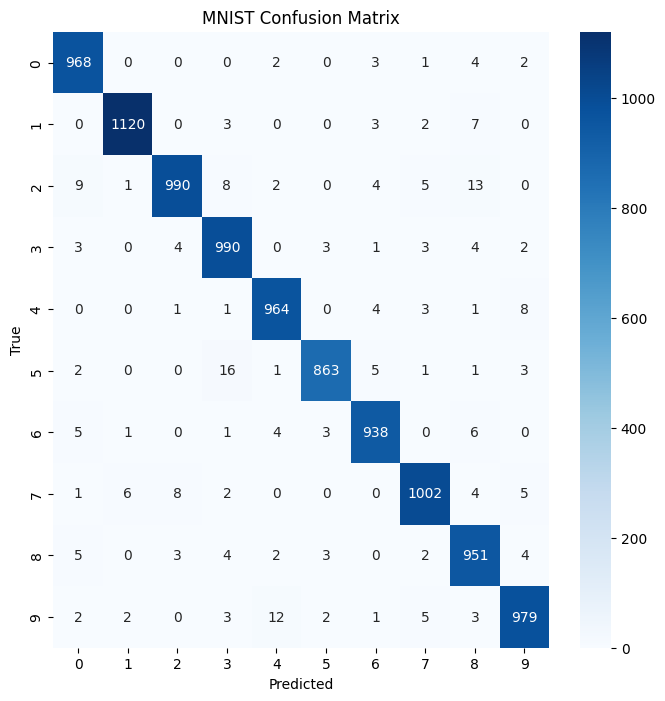

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("MNIST Confusion Matrix")
plt.show()

In [ ]:
misclassified_images = []
misclassified_preds = []
misclassified_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            if preds[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_preds.append(preds[i].cpu().item())
                misclassified_labels.append(labels[i].cpu().item())


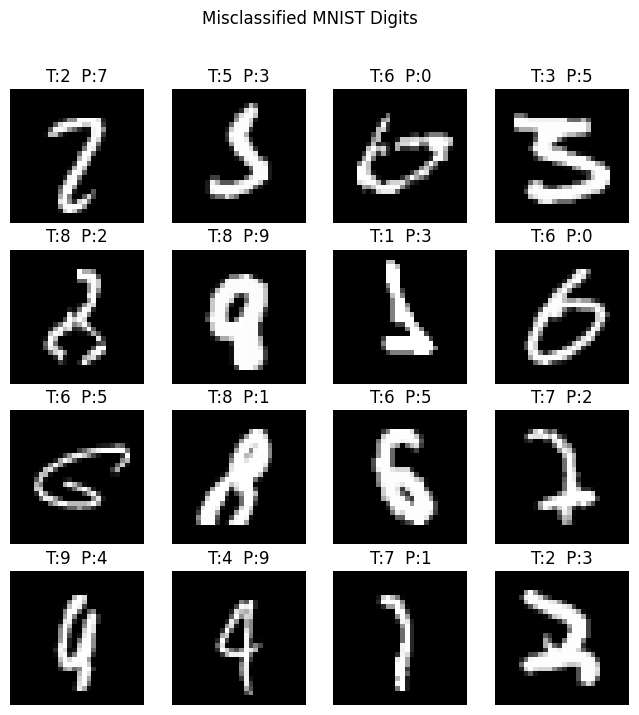

In [ ]:
def show_misclassified(images, preds, labels, n=16):
    plt.figure(figsize=(8,8))
    for i in range(n):
        plt.subplot(4,4,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title(f"T:{labels[i]}  P:{preds[i]}")
        plt.axis("off")
    plt.suptitle("Misclassified MNIST Digits")
    plt.show()

show_misclassified(misclassified_images, misclassified_preds, misclassified_labels, n=16)


## Conclusions and Error Analysis

After training, I loaded the best validation checkpoint and evaluated the model on the held-out test set. The final test accuracy was 99.23%. This confirms that the CNN is highly effective at recognizing handwritten digits, even across varied writing styles.

The confusion matrix shows that nearly all predictions fall along the diagonal, meaning most digits are classified correctly. The remaining errors tend to occur between visually similar digits such as 4 and 9, 5 and 3, and 2 and 7.

To better understand these mistakes, I visualized misclassified examples. Many of them involve ambiguous handwriting, incomplete strokes, or unusual writing styles that even humans might misinterpret. These errors highlight the inherent difficulty of handwriting recognition rather than a major weakness of the model.

Overall, the convolutional neural network significantly improves performance compared to a simple fully connected approach by leveraging spatial structure in images. This demonstrates the strength of CNNs for vision tasks and explains the model’s very high accuracy.